In [1]:
import numpy as np
import os
dataset_path = "/kaggle/input/garbage-dataset/garbage_classification"
classes = os.listdir(dataset_path)
print (f"Classes found: {classes}")
image_paths, labels = [], []
for label, class_name in enumerate(classes):
    class_dir = os.path.join(dataset_path, class_name)
    for img_name in os.listdir(class_dir):
        image_paths.append(os.path.join(class_dir, img_name))
        labels.append(label)

Classes found: ['metal', 'Plastic-bag', 'white-glass', 'biological', 'paper', 'battery', 'trash', 'cardboard', 'shoes', 'clothes', 'Bottle']


In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
import cv2
import tensorflow as tf
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import xgboost as xgb
from skimage import feature
import numpy as np
import warnings
warnings.filterwarnings('ignore')

2026-01-18 17:43:09.445571: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1768758189.467080     133 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1768758189.473672     133 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

In [3]:
import torch
import torchvision.models as models
import torchvision.transforms as transforms
from PIL import Image
import numpy as np
import os
from tqdm import tqdm

# CẤU HÌNH THAM SỐ
MODEL_NAME = 'resnet50'
FEATURE_DIMENSION = 2048 # Chiều đầu ra của ResNet50 (sau lớp pooling)
RESIZE_SIZE = 224        # Kích thước ảnh đầu vào tiêu chuẩn của ResNet
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# =========================================================
# TẢI MÔ HÌNH VÀ CẤU HÌNH TIỀN XỬ LÝ
# =========================================================
try:
    # Tải ResNet50 đã được huấn luyện trên ImageNet
    model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
    
    # Loại bỏ lớp phân loại cuối cùng (fc)
    # Chúng ta chỉ lấy đến lớp Global Average Pooling để có vector 2048 chiều
    model = torch.nn.Sequential(*(list(model.children())[:-1]))
    
    model.to(DEVICE)
    model.eval()
    print(f" Đã tải mô hình {MODEL_NAME} và sẵn sàng trích xuất đặc trưng.")

except Exception as e:
    print(f" Lỗi tải ResNet: {e}")
    model = None
    exit()

# Định nghĩa Preprocessing Transform
preprocess_transform = transforms.Compose([
    transforms.Resize((RESIZE_SIZE, RESIZE_SIZE)),
    transforms.ToTensor(),
    # Chuẩn hóa theo tiêu chuẩn của ImageNet
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# =========================================================
# HÀM TRÍCH XUẤT ĐẶC TRƯNG CHÍNH
# =========================================================
def get_resnet_features(image_path):
    """Trích xuất vector đặc trưng 2048 chiều từ ảnh bằng ResNet50."""
    if model is None: return None
    try:
        image = Image.open(image_path).convert('RGB')
        image_tensor = preprocess_transform(image).unsqueeze(0).to(DEVICE)
        
        with torch.no_grad():
            features = model(image_tensor)
        
        # Làm phẳng vector đầu ra (từ [1, 2048, 1, 1] thành [2048])
        return features.cpu().numpy().flatten()
    except Exception as e:
        return None

 Đã tải mô hình resnet50 và sẵn sàng trích xuất đặc trưng.


In [4]:

# 1. TRÍCH XUẤT ĐẶC TRƯNG VÀ LỌC DỮ LIỆU

resnet_features_list = []
valid_labels = []
valid_image_paths = [] # Thu thập đường dẫn ảnh hợp lệ

print(f"Bắt đầu trích xuất ResNet features cho {len(image_paths)} ảnh...")

# Thay thế bằng hàm trích xuất ResNet
for path, label in tqdm(zip(image_paths, labels), total=len(image_paths)):
    feat = get_resnet_features(path)
    if feat is not None:
        resnet_features_list.append(feat)
        valid_labels.append(label)
        valid_image_paths.append(path)

X = np.array(resnet_features_list)
y = np.array(valid_labels)

print(f"\nHoàn thành trích xuất. Kích thước X: {X.shape}, y: {y.shape}")

Bắt đầu trích xuất ResNet features cho 15376 ảnh...


100%|██████████| 15376/15376 [02:58<00:00, 86.15it/s]



Hoàn thành trích xuất. Kích thước X: (15376, 2048), y: (15376,)


In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import joblib

TEST_SIZE_RATIO = 0.2
VALID_SIZE_RATIO = 0.2 

# 2. CHIA TẬP DỮ LIỆU 

temp_size = TEST_SIZE_RATIO + VALID_SIZE_RATIO 
X_train, X_temp, y_train, y_temp, paths_train, paths_temp = train_test_split(
    X, 
    y, 
    valid_image_paths, 
    test_size=temp_size, 
    random_state=42, 
    stratify=y
)

valid_test_ratio = TEST_SIZE_RATIO / temp_size 
X_valid, X_test, y_valid, y_test, paths_valid, paths_test = train_test_split(
    X_temp, 
    y_temp, 
    paths_temp,
    test_size=valid_test_ratio,
    random_state=42, 
    stratify=y_temp 
)


# 3. STANDARD SCALING (BẮT BUỘC cho ResNet)

scaler = StandardScaler() 

# 3A. FIT và TRANSFORM trên tập TRAIN
X_train_scaled = scaler.fit_transform(X_train) 

# 3B. CHỈ TRANSFORM trên tập VALID và TEST
X_valid_scaled = scaler.transform(X_valid)
X_test_scaled = scaler.transform(X_test)

# 3C. LƯU SCALER CHO DEMO WEB
joblib.dump(scaler, 'scaler_resnet_features.joblib')

# 4. KIỂM TRA KÍCH THƯỚC VÀ CHUẨN BỊ CHO SVM

print(f"Mean của X_train_scaled : {X_train_scaled.mean():.4f}")
print(f"Std dev của X_train_scaled : {X_train_scaled.std():.4f}")
print(f"Đã lưu scaler vào 'scaler_resnet_features.joblib'.")


Mean của X_train_scaled : -0.0000
Std dev của X_train_scaled : 1.0000
Đã lưu scaler vào 'scaler_resnet_features.joblib'.


In [6]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
import numpy as np

#  THAM SỐ CỐ ĐỊNH BAN ĐẦU 
FIXED_C = 1.0
FIXED_GAMMA = 'scale'

# BƯỚC 1: HUẤN LUYỆN SVM VỚI THAM SỐ CỐ ĐỊNH

print(f"HUẤN LUYỆN MÔ HÌNH SVM CƠ SỞ (C={FIXED_C}, Gamma='{FIXED_GAMMA}')")

# Khởi tạo và huấn luyện mô hình trên tập TRAIN
fixed_svm_model = SVC(
    kernel='rbf',       
    C=FIXED_C,              
    gamma=FIXED_GAMMA,      
    random_state=42     
)

fixed_svm_model.fit(X_train, y_train)

print("Huấn luyện hoàn tất.")

HUẤN LUYỆN MÔ HÌNH SVM CƠ SỞ (C=1.0, Gamma='scale')
Huấn luyện hoàn tất.


In [7]:
# BƯỚC 2: ĐÁNH GIÁ VÀ BÁO CÁO TRÊN TẬP VALIDATION
# 1. Dự đoán trên tập Validation
y_pred_valid = fixed_svm_model.predict(X_valid)
valid_accuracy = accuracy_score(y_valid, y_pred_valid)
print(f"ĐỘ CHÍNH XÁC trên tập Thẩm định (Validation): {valid_accuracy:.4f}")

ĐỘ CHÍNH XÁC trên tập Thẩm định (Validation): 0.9789


In [8]:
# 2. Báo cáo Phân loại trên Validation
num_classes = len(classes)
all_labels = list(range(num_classes)) 

print("\nValidation (Classification Report):")
print(classification_report(y_valid, y_pred_valid, target_names=classes, labels=all_labels))
print("-" * 60)


Validation (Classification Report):
              precision    recall  f1-score   support

       metal       0.90      0.98      0.94       155
 Plastic-bag       0.99      0.98      0.99       142
 white-glass       0.96      0.95      0.95       155
  biological       0.99      0.99      0.99       197
       paper       0.97      0.95      0.96       211
     battery       1.00      0.97      0.98       189
       trash       1.00      0.99      0.99       140
   cardboard       0.95      0.97      0.96       178
       shoes       0.96      0.99      0.97       395
     clothes       0.99      0.99      0.99      1065
      Bottle       1.00      0.96      0.98       248

    accuracy                           0.98      3075
   macro avg       0.97      0.97      0.97      3075
weighted avg       0.98      0.98      0.98      3075

------------------------------------------------------------


In [9]:
# BƯỚC 3: ĐÁNH GIÁ VÀ BÁO CÁO TRÊN TẬP TEST 
# 1. Dự đoán trên tập Test
y_pred_test = fixed_svm_model.predict(X_test)
test_accuracy = accuracy_score(y_test, y_pred_test)
print(f"ĐỘ CHÍNH XÁC trên tập Kiểm thử (Test): {test_accuracy:.4f}")

ĐỘ CHÍNH XÁC trên tập Kiểm thử (Test): 0.9701


In [10]:
# 2. Báo cáo Phân loại trên Test
print("\nTest (Classification Report):")
print(classification_report(y_test, y_pred_test, target_names=classes, labels=all_labels))


Test (Classification Report):
              precision    recall  f1-score   support

       metal       0.89      0.93      0.91       154
 Plastic-bag       0.98      0.98      0.98       142
 white-glass       0.95      0.93      0.94       155
  biological       0.94      0.99      0.97       197
       paper       0.93      0.92      0.93       212
     battery       0.97      0.99      0.98       189
       trash       0.98      0.93      0.95       139
   cardboard       0.95      0.93      0.94       178
       shoes       0.96      0.99      0.98       396
     clothes       1.00      0.99      0.99      1065
      Bottle       0.99      0.97      0.98       249

    accuracy                           0.97      3076
   macro avg       0.96      0.96      0.96      3076
weighted avg       0.97      0.97      0.97      3076



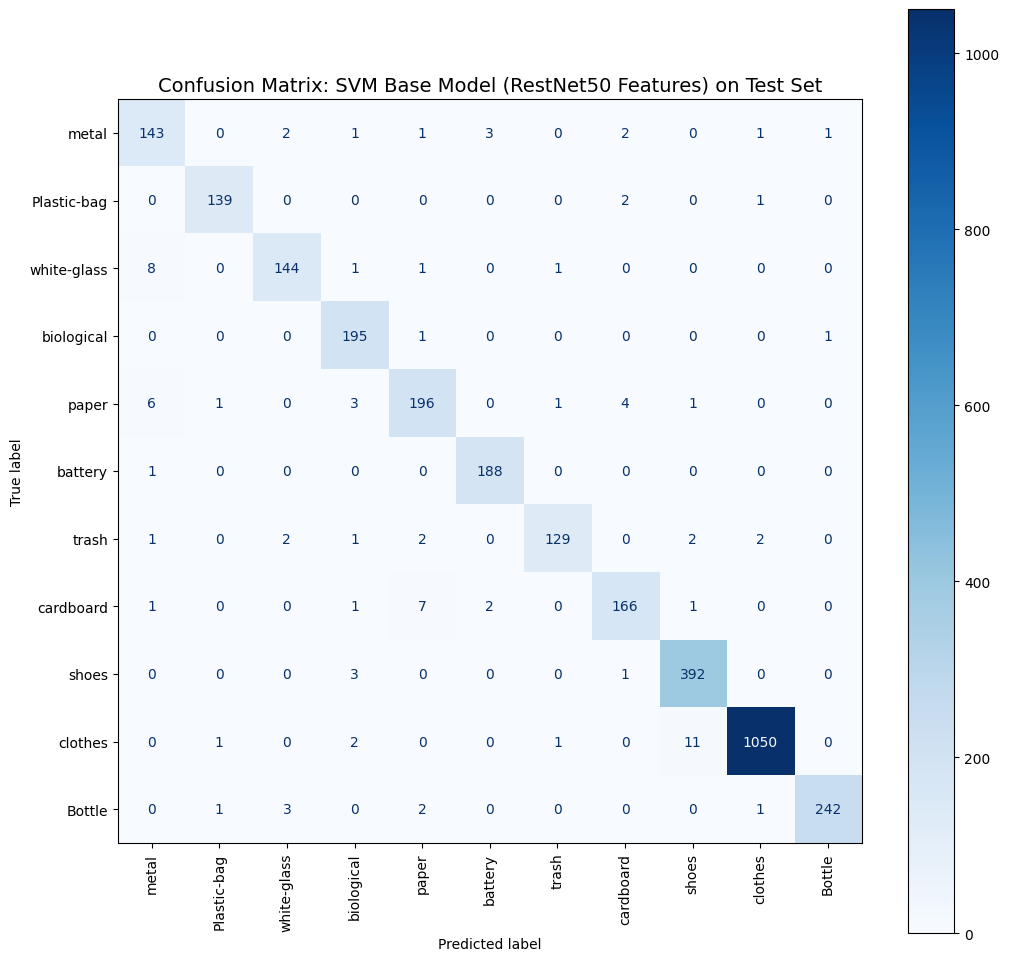


Ma trận nhầm lẫn đã được tính toán và lưu thành công dưới dạng file: confusion_matrix_svm_baseline_test.png


In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Tính toán Ma trận nhầm lẫn
num_classes = len(classes)
all_labels = list(range(num_classes)) 

cm = confusion_matrix(
    y_test, 
    y_pred_test, 
    labels=all_labels # Đảm bảo ma trận có kích thước 11x11
)

# 2. Trực quan hóa Confusion Matrix

fig, ax = plt.subplots(figsize=(12, 12)) 
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)

disp.plot(cmap=plt.cm.Blues, xticks_rotation='vertical', ax=ax)
plt.title('Confusion Matrix: SVM Base Model (RestNet50 Features) on Test Set', fontsize=14)

# 3. Lưu hình ảnh
file_name = "confusion_matrix_svm_baseline_test.png" 
plt.savefig(file_name, bbox_inches='tight', dpi=300) 

plt.show() 

print(f"\nMa trận nhầm lẫn đã được tính toán và lưu thành công dưới dạng file: {file_name}")

HIỂN THỊ 2 ẢNH ĐƯỢC PHÂN LOẠI ĐÚNG NGẪU NHIÊN TRÊN TẬP TEST (Tổng: 2984 ảnh)


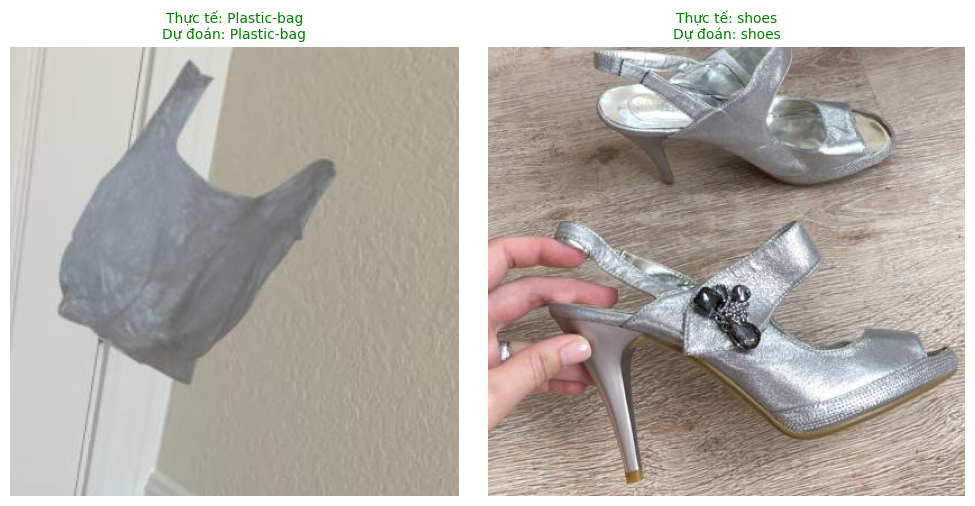

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 

correctly_classified_mask = (y_test == y_pred_test)
indices_in_test_set = np.where(correctly_classified_mask)[0]
num_correctly_classified = len(indices_in_test_set)

print(f"HIỂN THỊ 2 ẢNH ĐƯỢC PHÂN LOẠI ĐÚNG NGẪU NHIÊN TRÊN TẬP TEST (Tổng: {num_correctly_classified} ảnh)")

# Chọn số lượng ảnh muốn hiển thị
num_to_display = min(2, num_correctly_classified) 


if num_correctly_classified > 0:
    # Lấy ngẫu nhiên 'num_to_display' chỉ mục
    random_correct_indices = np.random.choice(
        indices_in_test_set, 
        size=num_to_display, 
        replace=False 
    )
    
    # Khởi tạo figure chỉ khi có mẫu để hiển thị
    fig, axes = plt.subplots(1, num_to_display, figsize=(10, 5))
    
    # Xử lý trường hợp chỉ hiển thị 1 ảnh
    if num_to_display == 1:
        axes = [axes] 

    for i in range(num_to_display):
        # Lấy chỉ mục đã chọn ngẫu nhiên
        test_idx = random_correct_indices[i] 
        
        # Lấy thông tin nhãn
        true_label = y_test[test_idx]
        pred_label = y_pred_test[test_idx]
        true_class_name = classes[true_label]
        predicted_class_name = classes[pred_label]
        
        # *** ĐỌC ẢNH GỐC TỪ ĐƯỜNG DẪN paths_test ***
        image_path = paths_test[test_idx] 
        image = cv2.imread(image_path)
        
        if image is None:
            image_rgb = np.zeros((128, 128, 3), dtype=np.uint8) 
            title_color = 'gray'
        else:
            # Chuyển từ BGR (OpenCV) sang RGB (Matplotlib)
            image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            # Màu xanh lá cho dự đoán đúng
            title_color = 'green' 
        
        # Hiển thị ảnh
        axes[i].imshow(image_rgb)
        axes[i].set_title(f"Thực tế: {true_class_name}\nDự đoán: {predicted_class_name}", 
                          color=title_color, fontsize=10)
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

else:
    print(" Không có bất kỳ mẫu nào được phân loại đúng trong tập Test. Không thể hiển thị hình ảnh.")

HIỂN THỊ 2 ẢNH BỊ PHÂN LOẠI SAI NGẪU NHIÊN TRÊN TẬP TEST (Tổng: 92 ảnh)


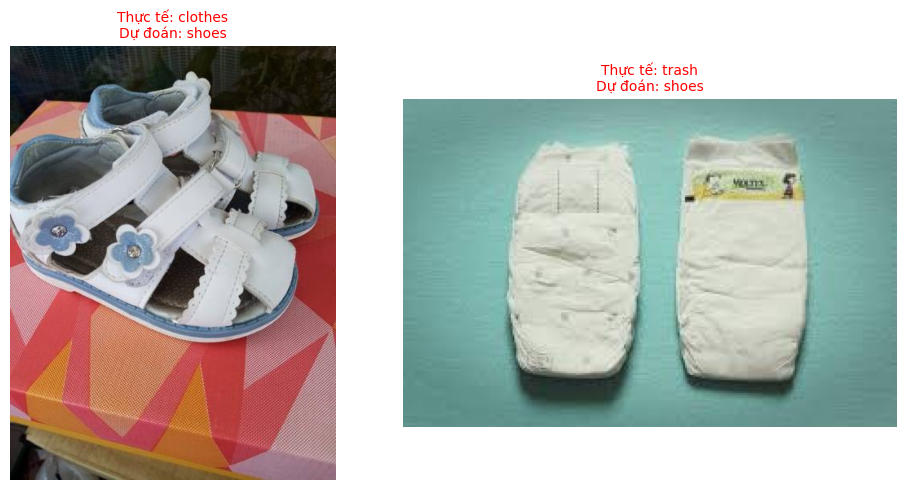

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 

# 1. Tìm các chỉ mục (indices) nơi dự đoán SAI
misclassified_mask = (y_test != y_pred_test)
indices_in_test_set = np.where(misclassified_mask)[0]
num_misclassified = len(indices_in_test_set)


print(f"HIỂN THỊ 2 ẢNH BỊ PHÂN LOẠI SAI NGẪU NHIÊN TRÊN TẬP TEST (Tổng: {num_misclassified} ảnh)")


# Chọn số lượng ảnh muốn hiển thị
num_to_display = min(2, num_misclassified) 


if num_misclassified > 0:
    # Lấy ngẫu nhiên 'num_to_display' chỉ mục
    random_misclassified_indices = np.random.choice(
        indices_in_test_set, 
        size=num_to_display, 
        replace=False 
    )
    
    # Khởi tạo figure chỉ khi có mẫu để hiển thị
    fig, axes = plt.subplots(1, num_to_display, figsize=(10, 5))
    
    # Xử lý trường hợp chỉ hiển thị 1 ảnh
    if num_to_display == 1:
        axes = [axes] 

    for i in range(num_to_display):
        # Lấy chỉ mục đã chọn ngẫu nhiên
        test_idx = random_misclassified_indices[i] 
        
        # Lấy thông tin nhãn
        true_label = y_test[test_idx]
        pred_label = y_pred_test[test_idx]
        true_class_name = classes[true_label]
        predicted_class_name = classes[pred_label]
        
        # *** ĐỌC ẢNH GỐC TỪ ĐƯỜNG DẪN paths_test ***
        image_path = paths_test[test_idx] 
        image = cv2.imread(image_path)
        
        if image is None:
            image_rgb = np.zeros((128, 128, 3), dtype=np.uint8) 
            title_color = 'gray'
        else:
            # Chuyển từ BGR (OpenCV) sang RGB (Matplotlib)
            image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            # Màu đỏ cho dự đoán sai
            title_color = 'red' 
        
        # Hiển thị ảnh
        axes[i].imshow(image_rgb)
        axes[i].set_title(f"Thực tế: {true_class_name}\nDự đoán: {predicted_class_name}", 
                          color=title_color, fontsize=10)
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

else:
    print("Không có mẫu nào bị phân loại sai trong tập Test. (Chúc mừng! Hoặc kiểm tra lại dữ liệu). Không thể hiển thị hình ảnh.")

In [14]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
import time

# BƯỚC 1: XÁC ĐỊNH LƯỚI THAM SỐ VÀ KHỞI TẠO GRID SEARCH

# Phạm vi các giá trị C và gamma cần thử nghiệm
param_grid = {
    'C': [0.1, 1, 10,100], # Thử nghiệm các giá trị C khác nhau
    'gamma': ['scale', 0.01, 0.1], # Thử nghiệm các giá trị gamma khác nhau
    'kernel': ['rbf'] 
}

base_svm = SVC(random_state=42)

print("BẮT ĐẦU TỐI ƯU THAM SỐ SVM (GRID SEARCH CV) TRÊN TẬP TRAIN")

start_time = time.time()

# Grid Search sẽ tìm kiếm tham số tốt nhất qua 3-fold Cross-Validation trên X_train
grid_search = GridSearchCV(
    estimator=base_svm, 
    param_grid=param_grid, 
    cv=3, 
    verbose=2, 
    n_jobs=-1, # Sử dụng tất cả các lõi CPU
    scoring='accuracy' 
)

# Chạy tìm kiếm
grid_search.fit(X_train, y_train)

end_time = time.time()
print(f"\nThời gian chạy Grid Search: {end_time - start_time:.2f} giây")
print("-"*60)

# BƯỚC 2: ĐÁNH GIÁ MÔ HÌNH TỐT NHẤT TRÊN TẬP TEST

# Lấy mô hình SVM tốt nhất đã được tối ưu
best_svm_model = grid_search.best_estimator_

print(f"Tham số TỐT NHẤT tìm được: {grid_search.best_params_}")
print(f"Độ chính xác TỐT NHẤT (Cross-Validation trên Train): {grid_search.best_score_:.4f}")
print("-" * 60)

# Dự đoán trên tập Test BẰNG MÔ HÌNH TỐT NHẤT
y_pred_final = best_svm_model.predict(X_test)

# 1. Độ chính xác cuối cùng
final_accuracy = accuracy_score(y_test, y_pred_final)
print(f"Độ chính xác CUỐI CÙNG trên tập TEST: {final_accuracy:.4f}")

# 2. Báo cáo Phân loại cuối cùng
num_classes = len(classes)
all_labels = list(range(num_classes)) 

print("\n(Classification Report trên Test:")
print(classification_report(y_test, y_pred_final, target_names=classes, labels=all_labels))
print("-"*60)

BẮT ĐẦU TỐI ƯU THAM SỐ SVM (GRID SEARCH CV) TRÊN TẬP TRAIN
Fitting 3 folds for each of 12 candidates, totalling 36 fits

Thời gian chạy Grid Search: 1475.04 giây
------------------------------------------------------------
Tham số TỐT NHẤT tìm được: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Độ chính xác TỐT NHẤT (Cross-Validation trên Train): 0.9743
------------------------------------------------------------
Độ chính xác CUỐI CÙNG trên tập TEST: 0.9714

(Classification Report trên Test:
              precision    recall  f1-score   support

       metal       0.91      0.94      0.93       154
 Plastic-bag       0.99      0.98      0.98       142
 white-glass       0.96      0.94      0.95       155
  biological       0.95      0.99      0.97       197
       paper       0.94      0.94      0.94       212
     battery       0.98      0.99      0.98       189
       trash       0.98      0.93      0.96       139
   cardboard       0.97      0.94      0.95       178
       shoes     

MA TRẬN NHẦM LẪN (CONFUSION MATRIX) CHO MÔ HÌNH TỐI ƯU TRÊN TẬP TEST


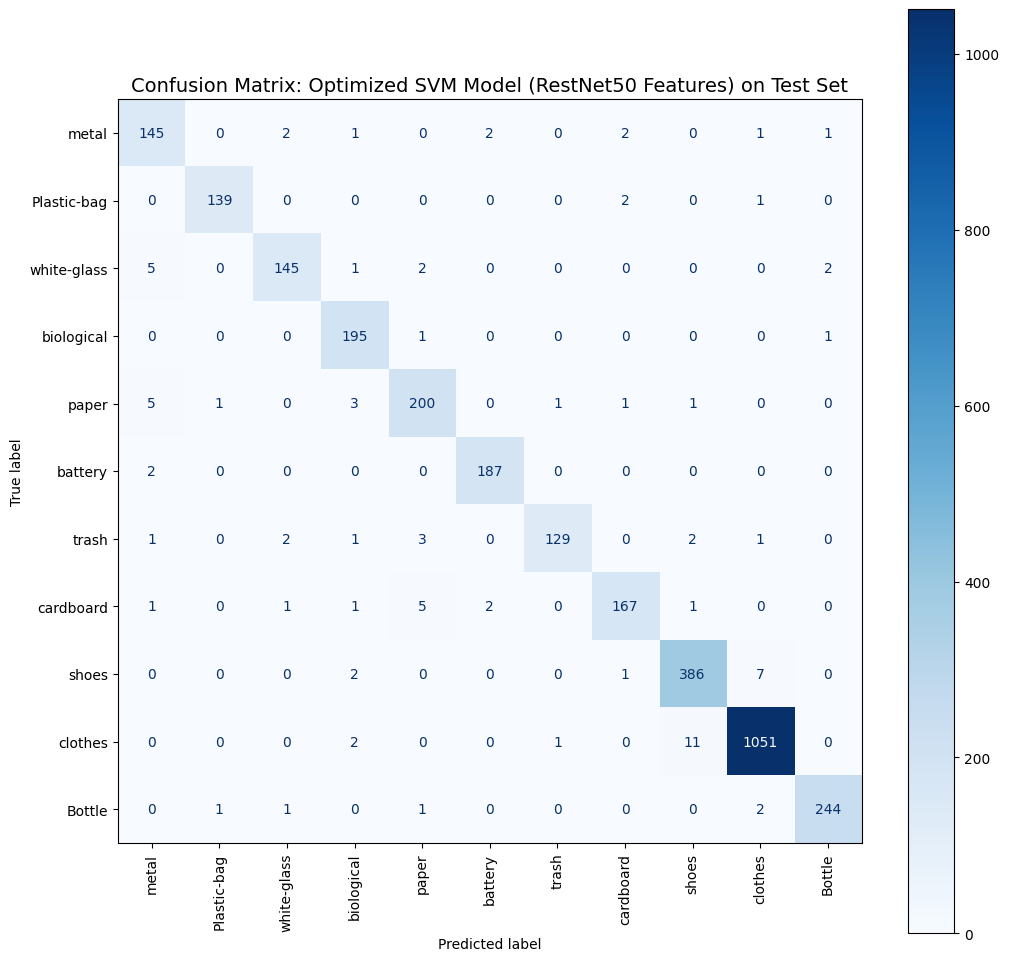


Ma trận nhầm lẫn đã được tính toán và lưu thành công dưới dạng file: confusion_matrix_svm_optimized_hist_test.png


In [15]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Tính toán Ma trận nhầm lẫn
num_classes = len(classes)
all_labels = list(range(num_classes)) 

cm = confusion_matrix(
    y_test, 
    y_pred_final, 
    labels=all_labels # Đảm bảo ma trận có kích thước đầy đủ
)

# 2. Trực quan hóa Ma trận nhầm lẫn

print("MA TRẬN NHẦM LẪN (CONFUSION MATRIX) CHO MÔ HÌNH TỐI ƯU TRÊN TẬP TEST")

# Khởi tạo figure
fig, ax = plt.subplots(figsize=(12, 12)) 
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes) 

# Hiển thị ma trận
disp.plot(cmap=plt.cm.Blues, xticks_rotation='vertical', ax=ax)
plt.title('Confusion Matrix: Optimized SVM Model (RestNet50 Features) on Test Set', fontsize=14)

# 3. Lưu hình ảnh
file_name = "confusion_matrix_svm_optimized_hist_test.png" 
plt.savefig(file_name, bbox_inches='tight', dpi=300) 

plt.show() 

print(f"\nMa trận nhầm lẫn đã được tính toán và lưu thành công dưới dạng file: {file_name}")

In [16]:
import joblib
import os 
import time

timestamp = time.strftime("%Y%m%d_%H%M%S")
file_name = f"best_svm_ResNet50_model_{timestamp}.joblib"


# BƯỚC 1: LƯU MÔ HÌNH

print("-"*60)
print(f"BẮT ĐẦU LƯU MÔ HÌNH SVM TỐT NHẤT")
print("-"*60)

try:
    # Lưu mô hình (và các tham số đã được tối ưu) vào file
    joblib.dump(best_svm_model, file_name)
    
    print(f"Mô hình đã được lưu thành công tại: {os.path.abspath(file_name)}")
    print(f"Tham số: {best_svm_model.get_params()}")
except Exception as e:
    print(f"Lỗi khi lưu mô hình: {e}")

print("-"*60)

------------------------------------------------------------
BẮT ĐẦU LƯU MÔ HÌNH SVM TỐT NHẤT
------------------------------------------------------------
Mô hình đã được lưu thành công tại: /kaggle/working/best_svm_ResNet50_model_20260118_181212.joblib
Tham số: {'C': 10, 'break_ties': False, 'cache_size': 200, 'class_weight': None, 'coef0': 0.0, 'decision_function_shape': 'ovr', 'degree': 3, 'gamma': 'scale', 'kernel': 'rbf', 'max_iter': -1, 'probability': False, 'random_state': 42, 'shrinking': True, 'tol': 0.001, 'verbose': False}
------------------------------------------------------------
